# NetSentinel: from anomaly-detection notebook to threat-detection platform

This notebook tells the story of the project from the original `Anomaly_detection.ipynb`
(preserved unchanged in `original/`) to the deployed platform. It **reads saved results**:

* `artifacts/v0/report.json`: the original notebook, reproduced as a script
* `artifacts/v1/report.json`: the production model and its evaluations
* `artifacts/e2e/*.json`: end-to-end validation runs of the live platform

Production code lives in the `netsentinel` package. This notebook imports it; nothing imports the notebook.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from netsentinel.ml import data, schema, taxonomy

ROOT = data.ROOT
v0 = json.loads((ROOT / "artifacts/v0/report.json").read_text())
v1 = json.loads((ROOT / "artifacts/v1/report.json").read_text())

# Chart style: one hue for single-series charts, recessive grid, text in ink colours.
BLUE, INK2, GRID = "#2a78d6", "#52514e", "#e1e0d9"
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK2, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
                     "figure.dpi": 110})
pd.set_option("display.max_colwidth", 90)

## 1. The data: CICIDS-2017

Five days of CICFlowMeter flows from the Canadian Institute for Cybersecurity testbed. Each day
contains different attacks, which matters for how the data is split.

In [2]:
labels = pd.concat({d: pd.read_parquet(data.CACHE / f"{d}.parquet", columns=["Label", "Attempted Category"])
                    for d in data.DAYS_CHRONOLOGICAL}, names=["day"]).reset_index(level=0).reset_index(drop=True)
pd.crosstab(labels["Label"], labels["day"])[list(data.DAYS_CHRONOLOGICAL)]

day,monday,tuesday,wednesday,thursday,friday
Label,,,,,
BENIGN,371621,315106,319119,288171,288544
Botnet,0,0,0,0,736
Botnet - Attempted,0,0,0,0,4067
DDoS,0,0,0,0,95144
DoS GoldenEye,0,0,7567,0,0
DoS GoldenEye - Attempted,0,0,80,0,0
DoS Hulk,0,0,158468,0,0
DoS Hulk - Attempted,0,0,581,0,0
DoS Slowhttptest,0,0,1740,0,0


## 2. What the original notebook got wrong

| Issue | Evidence | Consequence |
|---|---|---|
| **Target leakage** | `Attempted Category` is a model feature, and is ≠ −1 *exactly* on `… - Attempted` labels (next cell) | the model can read part of the answer |
| **Not a time split** | Hugging Face loads files alphabetically (fri, mon, thu, tue, wed), so the "future" 30% is Tuesday + Wednesday | test attacks (all DoS, Heartbleed) never appear in training |
| **Identity features** | `Src IP dec` / `Dst IP dec` rank #4 and #7 in importance | memorises the lab's addresses, not attack behaviour |
| **ROC-AUC from hard labels** | `roc_auc_score(y, y_pred)` for two models | reports balanced accuracy and calls it AUC |
| **Binary only** | 0 / 1 output | no triage information |

In [3]:
attempted_flag = labels["Attempted Category"] != -1
attempted_label = labels["Label"].str.endswith("- Attempted")
pd.crosstab(attempted_flag.rename("Attempted Category != -1"), attempted_label.rename("label ends with '- Attempted'"))

label ends with '- Attempted',False,True
Attempted Category != -1,,
False,2087992,0
True,0,11979


In [4]:
print("Notebook's test split comes from:", v0["data"]["test_days"])
test_labels = pd.Series(v0["data"]["test_labels"]).drop("BENIGN").sort_values(ascending=False)
test_labels.rename("flows in the notebook's test split").to_frame()

Notebook's test split comes from: {'wednesday': 496632, 'tuesday': 132410}


,flows in the notebook's test split
DoS Hulk,158468
DoS GoldenEye,7567
DoS Slowloris,3859
DoS Slowhttptest - Attempted,3368
FTP-Patator,2465
DoS Slowloris - Attempted,1847
SSH-Patator,1838
DoS Slowhttptest,1740
DoS Hulk - Attempted,581
DoS GoldenEye - Attempted,80


## 3. v0: the notebook, reproduced exactly

`python -m netsentinel.ml.train v0` replays the notebook from the raw CSVs, keeping its flaws on
purpose. The data pipeline reproduces **exactly**. Random Forest does **not**: with the same data, the
same seed and the same settings, the number of attacks it catches depends on the scikit-learn version.

In [5]:
ref = v0["notebook_reference"]
pd.DataFrame({
    "notebook": [ref["duplicates"], ref["correlated_dropped"], ref["train_rows"], ref["test_rows"],
                 str(ref["confusion_matrix"]["isolation_forest"])],
    "v0": [v0["data"]["duplicates_removed"], len(v0["data"]["correlated_dropped"]), v0["data"]["train_rows"],
           v0["data"]["test_rows"], str(v0["models"]["isolation_forest"]["confusion_matrix"])],
}, index=["duplicates removed", "correlated features dropped", "train rows", "test rows",
          "Isolation Forest confusion matrix"])

,notebook,v0
duplicates removed,3167,3167
correlated features dropped,27,27
train rows,1467762,1467762
test rows,629042,629042
Isolation Forest confusion matrix,"[[346254, 100939], [1851, 179998]]","[[346254, 100939], [1851, 179998]]"


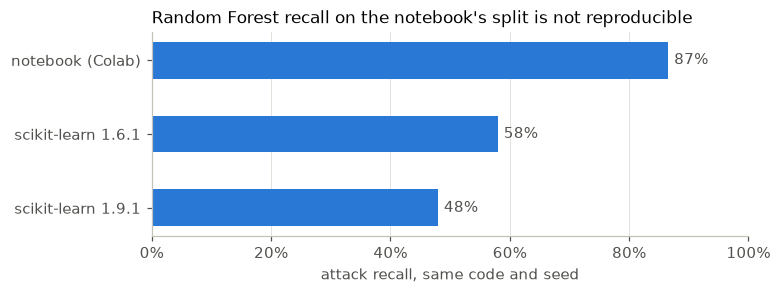

In [6]:
support = v0["data"]["test_attacks"]
runs = {"notebook (Colab)": ref["confusion_matrix"]["random_forest"][1][1],
        "scikit-learn 1.6.1": 105_439,          # measured, see docs/model-baseline.md
        "scikit-learn 1.9.1": v0["models"]["random_forest"]["confusion_matrix"][1][1]}
recall = {k: v / support for k, v in runs.items()}
fig, ax = plt.subplots(figsize=(7, 2.4))
bars = ax.barh(list(recall), list(recall.values()), color=BLUE, height=0.5)
ax.bar_label(bars, labels=[f"{v:.0%}" for v in recall.values()], padding=4, color=INK2)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter("{x:.0%}"); ax.set_xlabel("attack recall, same code and seed"); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_title("Random Forest recall on the notebook's split is not reproducible", loc="left", fontsize=11)
plt.show()

Why: the test attacks (DoS variants, Heartbleed) are absent from training, so whether a model flags
them depends on incidental tree splits. Per-label recall from the v0 run:

In [7]:
pd.Series(v0["rf_recall_by_attack_label"]).rename("RF recall (v0)").sort_values().to_frame().style.format("{:.1%}")

,RF recall (v0)
DoS GoldenEye - Attempted,0.0%
Heartbleed,0.0%
DoS Slowhttptest - Attempted,0.1%
DoS Slowhttptest,0.3%
DoS Slowloris,0.4%
DoS Slowloris - Attempted,7.7%
DoS Hulk - Attempted,13.1%
DoS GoldenEye,29.4%
DoS Hulk,50.7%
SSH-Patator,99.9%


In [8]:
pd.DataFrame({m: {"notebook 'ROC-AUC'": ref["roc_auc_as_printed"][m], "ROC-AUC (scores)": r["roc_auc"],
                   "PR-AUC": r["pr_auc"]} for m, r in v0["models"].items()}).T.style.format("{:.4f}")

,notebook 'ROC-AUC',ROC-AUC (scores),PR-AUC
isolation_forest,0.8821,0.8657,0.5653
random_forest,0.9999,0.9999,0.9995
logistic_regression,0.7962,0.9638,0.9620


## 4. v1: fixed schema and a hierarchical detector

**Binary vs multi-class.** The notebook answers one question, *is this flow an attack?* v1 keeps that
as stage 1, the only stage that decides anything, and adds two descriptive stages that answer only when
confident enough:

```
Network event ─► Stage 1: Normal vs Attack         (decides; threshold tuned to ≤ 0.1% false alerts)
                     └─► Stage 2: attack family      (answers at ≥ 0.6 confidence, else "unknown")
                             └─► Stage 3: attack type (answers at ≥ 0.8 confidence, else none)
```

A flow the family model can't name is still an attack. Families and types are only learned once
they have enough training examples (`netsentinel/ml/taxonomy.py`).

In [9]:
print(len(schema.FEATURES), "model features; removed:")
pd.Series(schema.EXCLUDED, name="reason").to_frame()

83 model features; removed:


,reason
Attempted Category,target leakage: non-(-1) exactly on '- Attempted' labels
Src IP dec,"host identity: memorises lab topology, not behaviour"
Dst IP dec,"host identity: memorises lab topology, not behaviour"
Src Port,ephemeral client port: noise that encodes the capture's OS/port allocator
Timestamp,only mm:ss.f in this dataset; not a behavioural feature


In [10]:
pd.DataFrame([{"dataset label": k, "family": v.family or "Normal", "type": v.attack_type or "", "attempted": v.attempted}
              for k, v in taxonomy.LABELS.items()]).sort_values(["family", "type", "attempted"]).set_index("dataset label")

,family,type,attempted
dataset label,,,
Botnet,Botnet,Ares,False
Botnet - Attempted,Botnet,Ares,True
FTP-Patator,BruteForce,FTP-Patator,False
FTP-Patator - Attempted,BruteForce,FTP-Patator,True
SSH-Patator,BruteForce,SSH-Patator,False
SSH-Patator - Attempted,BruteForce,SSH-Patator,True
DDoS,DDoS,LOIC,False
DDoS - Attempted,DDoS,LOIC,True
DoS GoldenEye,DoS,GoldenEye,False


In [11]:
e1 = v1["e1"]
pd.DataFrame({name: {"threshold": m["threshold"], "false alerts": m["confusion_matrix"][0][1],
                     "missed attacks": m["confusion_matrix"][1][0], "precision": m["attack"]["precision"],
                     "recall": m["attack"]["recall"], "false-positive rate": m["false_positive_rate"]}
              for name, m in [("operational (≤0.1% FPR)", e1["fpr_0.1pct"]), ("max F1", e1["max_f1"])]}).T

,threshold,false alerts,missed attacks,precision,recall,false-positive rate
operational (≤0.1% FPR),0.000399,265.0,1.0,0.996821,0.999988,0.000930
max F1,0.611064,31.0,15.0,0.999627,0.999819,0.000109


In [12]:
fam = pd.DataFrame(e1["family"]["per_family"]).T
typ = pd.DataFrame(e1["attack_type"]).T.add_prefix("type ")
fam.join(typ[["type coverage", "type accuracy_when_answered"]])

,support,coverage,accuracy_when_answered,type coverage,type accuracy_when_answered
Botnet,387.0,1.000000,1.000000,1.000000,1.000000
BruteForce,1393.0,1.000000,1.000000,1.000000,1.000000
DDoS,19029.0,1.000000,1.000000,1.000000,1.000000
DoS,35502.0,1.000000,1.000000,0.999915,0.999831
Exploit,2.0,1.000000,0.000000,0.000000,NaN
Infiltration,15.0,0.733333,0.000000,0.533333,0.000000
PortScan,26360.0,1.000000,0.999924,0.814643,0.989708
WebAttack,412.0,1.000000,0.995146,0.269417,0.783784


E1 (attack types seen in training) is near perfect. CICIDS-2017 is known to be easy when the same tools
appear in training and test, so treat it as a ceiling. The honest test is E2.

## 5. E2: attacks the model has never seen

For each family, the stage-1 detector is retrained **without** it and tested on whether it still flags
that family, at the same ≤ 0.1% false-alert budget.

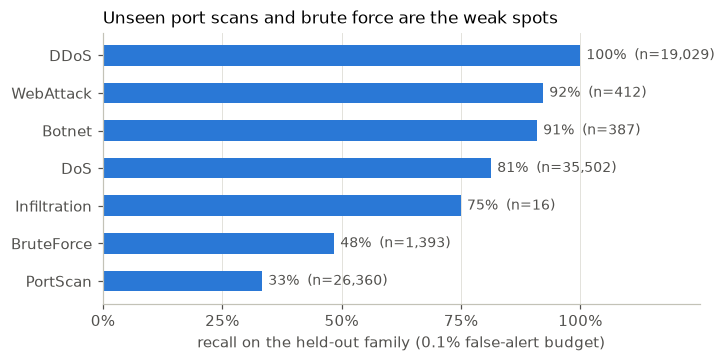

,test_support,supervised_recall,supervised_fpr,isolation_forest_recall
PortScan,26360.0,0.333725,0.001021,0.0
BruteForce,1393.0,0.484566,0.000926,0.0
Infiltration,16.0,0.750000,0.000922,0.0
DoS,35502.0,0.813363,0.000926,0.0
Botnet,387.0,0.909561,0.000908,0.0
WebAttack,412.0,0.922330,0.000961,0.0
DDoS,19029.0,1.000000,0.000908,0.0


In [13]:
e2 = pd.DataFrame(v1["e2"]["families"]).T.sort_values("supervised_recall")
fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(e2.index, e2["supervised_recall"], color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f"{r:.0%}  (n={int(n):,})" for r, n in zip(e2["supervised_recall"], e2["test_support"])],
             padding=4, color=INK2, fontsize=9)
ax.set_xlim(0, 1.25); ax.set_xticks([0, .25, .5, .75, 1]); ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("recall on the held-out family (0.1% false-alert budget)"); ax.grid(axis="y", visible=False)
ax.set_title("Unseen port scans and brute force are the weak spots", loc="left", fontsize=11)
plt.show()
e2[["test_support", "supervised_recall", "supervised_fpr", "isolation_forest_recall"]]

* A single scan or login attempt looks like a benign handshake. The attack is the *pattern* across many
  flows, which is why the platform correlates flows by source (the Orchestrator) and scores the source's
  port fan-out (the Risk Agent).
* An Isolation Forest trained on benign traffic catches **nothing** at this false-alert budget, so it is
  not in the alert path.

## 6. v2: per-source time windows

The weak spots above are attacks that only show up as a pattern across flows. v2 adds six features
that describe the **source's last 60 seconds**: flow count, distinct destination ports and hosts,
flows to the same service, and share of unanswered or reset flows. They are causal (computed from
flows that had already *ended*) and computed identically in training and in the live Detection Agent.

This needs real timestamps, which the Kaggle copy lost, so v2 uses the authors' corrected
CICIDS-2017 (Engelen et al., 2021). Both detectors below train on the same rows with the same splits.

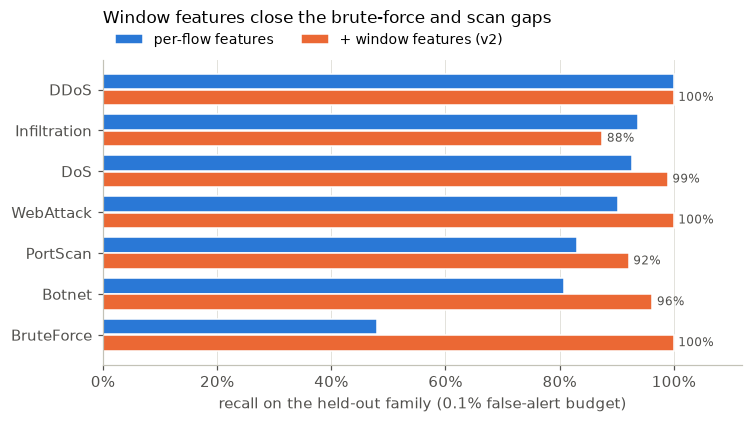

,per-flow features,+ window features (v2)
BruteForce,48.0%,100.0%
Botnet,80.7%,96.3%
PortScan,83.1%,92.1%
WebAttack,90.3%,100.0%
DoS,92.7%,99.0%
Infiltration,93.8%,87.5%
DDoS,100.0%,100.0%


In [14]:
v2r = json.loads((ROOT / "artifacts/v2/report-experiment.json").read_text())["results"]
cmp = pd.DataFrame({"per-flow features": {f: v["supervised_recall"] for f, v in v2r["v1-features"]["e2"]["families"].items()},
                    "+ window features (v2)": {f: v["supervised_recall"] for f, v in v2r["v2-features"]["e2"]["families"].items()}})
cmp = cmp.sort_values("per-flow features")
ORANGE = "#eb6834"
fig, ax = plt.subplots(figsize=(7.5, 3.6))
y = range(len(cmp))
b1 = ax.barh([i + 0.2 for i in y], cmp["per-flow features"], height=0.38, color=BLUE, label="per-flow features",
             edgecolor="white", linewidth=1)
b2 = ax.barh([i - 0.2 for i in y], cmp["+ window features (v2)"], height=0.38, color=ORANGE, label="+ window features (v2)",
             edgecolor="white", linewidth=1)
ax.set_yticks(list(y)); ax.set_yticklabels(cmp.index); ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter("{x:.0%}"); ax.grid(axis="y", visible=False)
ax.bar_label(b2, labels=[f"{v:.0%}" for v in cmp["+ window features (v2)"]], padding=3, color=INK2, fontsize=8)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, frameon=False, fontsize=9)
ax.set_xlabel("recall on the held-out family (0.1% false-alert budget)")
ax.set_title("Window features close the brute-force and scan gaps", loc="left", fontsize=11, pad=24)
plt.show()
cmp.style.format("{:.1%}")

Live check with v2 active: real capture intervals replayed through the production API, in the order
the flows ended. Port scan 997/997, FTP brute force 124/124, SSH brute force 102/102, botnet attempts
42/42, all named with the correct family. False alerts were 14 of 5,058 benign flows (0.28%, against
0.10% in validation), all just above a very low threshold. Re-tune the threshold on real traffic.
Details in `docs/model-v2.md`.

## 7. The platform

```
 sensors / replay ──► FastAPI ingest (API key, step 1) ──► Detection Agent (steps 2-7)
                                                              validate · normalise · extract
                                                              MODEL CHECK (hash + human approval)
                                                              inference ─► detection.attack (event bus)
                                                                              │
 Security Orchestrator ◄──────────────────────────────────────────────────────┘
   correlates flows by source + family into cases (step 7)
     └─► Investigation Agent: Claude, keyless, guarded (step 8)
           └─► Risk Assessment Agent: deterministic, explainable (step 9)
                 └─► Response Agent: reversible proposals only, human approval (step 10)
                       └─► Ticket Agent: NS-000123, SLA, timeline (step 11)
 Dashboard: read-only, HTTPS, signed sessions (step 12)
```

Every investigation and ticket keeps four labelled sections: **VERIFIED TELEMETRY**, **MODEL OUTPUT**,
**LLM ANALYSIS** and **RECOMMENDATION**. Claude never changes a detection or a risk score, and a guard
rejects any analysis that mentions an IP address absent from the evidence.

In [15]:
runs = sorted((ROOT / "artifacts/e2e").glob("*.json"), key=lambda p: p.stat().st_mtime)
if not runs:
    print("No end-to-end run yet: `netsentinel e2e`")
else:
    r = json.loads(runs[-1].read_text())
    print(f"Latest end-to-end validation ({r['run_started'][:16]} UTC): {'PASSED' if r['passed'] else 'FAILED'}")
    display(pd.Series(r["checks"], name="passed").to_frame())
    display(pd.DataFrame(r["tickets"]))

Latest end-to-end validation (2026-10-07T08:32 UTC): PASSED


,passed
1_ingest_all_accepted,True
2_malformed_rejected_with_reason,True
2_auth_no_key_401,True
2_auth_wrong_scope_403,True
6_all_valid_flows_scored,True
6_attack_recall_ge_0.99,True
6_false_positive_rate_le_0.005,True
7_every_attack_in_a_case,True
8_every_case_investigated,True
8_llm_ran_under_sandbox,True


,ticket,priority,status,case_to_ticket_s
0,NS-000090,P3,awaiting_approval,462.2
1,NS-000091,P2,awaiting_approval,512.3
2,NS-000092,P3,awaiting_approval,520.3
3,NS-000093,P3,awaiting_approval,588.3
4,NS-000094,P3,awaiting_approval,604.3
5,NS-000095,P4,awaiting_approval,710.4


## 8. Limitations and next steps

* **Threshold on real traffic:** v2 separates the lab data so well that its alert threshold is tiny
  (p ≥ 0.000016). Live replays gave 0.28% false alerts, not 0.10%. Re-tune on the target network, where
  busy legitimate hosts (NAT gateways, backup servers, scanners) produce fan-out too.
* **Sensors must send timestamps and the 5-tuple** for window features. Without them, flows fall back to
  per-flow scoring.
* **Lab data:** CICIDS-2017 is one network in 2017. Validate on live traffic (Zeek/NetFlow adapters are
  designed in) before trusting the numbers.
* **Closed-set families:** rare families (Infiltration, Heartbleed) get named as a wrong family instead
  of "unknown". An open-set check or more examples are needed.
* **Replay timestamps:** replayed flows are timestamped on arrival. Real sensors should send `observed_at`.